# Aritmética de Ponto Flutuante e Eliminação de Gauss



---


Este notebook foi originalmente produzido pelo professor Pedro Peixoto. Esta é uma versão adaptada para atender ao foco do curso atual.

**Leia com atenção:**


*   Você deve fazer obrigatoriamente todas as atividades marcadas com a exclamação❗.
*   Atividades marcadas com 🧩 são opcionais, mas interessantes, podendo ser desafiadoras.
*   Faça uma cópia do notebook para o seu Google Drive e use o Google Colab para executar o notebook e fazer a tarefa.
*   A atividade vai ser baseada no seu número USP para que as soluções dos alunos fiquem diferentes.
*   Há questões dissertativas!
*   Siga o passo a passo indicado no tutorial, respondendo às atividades propostas no seu jupyter notebook.
*   O notebook que entregar deve estar 100% funcional, isto é, todos os códigos rodando no Colab sem erros.
*   Você deverá entregar apenas uma cópia do jupyter notebook (.ipynb) no Classroom, na funcionalidade de "entregar" do Classroom.






---





Primeiro vamos carregar algumas bibliotecas: Numpy, Scipy Linear Algebra (scipy.linalg), System (sys) e Time (time)

In [ ]:
import numpy as np
import scipy.linalg as la
import sys
import time

Agora vamos definir alguns números especiais ("magic") para cada aluno, com base no seu número USP

In [ ]:
# Coloque aqui o seu número USP
nusp = 15452743

Estes números serão importantes para a atividade:

In [ ]:
magic_ilong = int(str(nusp).replace("0", ""))
magic_ishort = int(str(magic_ilong)[:2])
print("magic_ilong  =", magic_ilong)
print("magic_ishort =", magic_ishort)



---




## Aritmética de Ponto Flutuante

Começamos esse tutorial discutindo um pouco de aritmética de ponto flutuante, que vamos definir mais adiante.



Algumas referências:

[1]https://en.wikipedia.org/wiki/IEEE_754

[2] https://betterprogramming.pub/floating-point-numbers-are-weird-in-python-heres-how-to-fix-them-51336e4ad51a

[3] https://ironpython-test.readthedocs.io/en/latest/tutorial/floatingpoint.html


A matemática está furada no computador?

In [ ]:
a = 10
b = 0.1
c = 0.2

In [ ]:
r1 = a * (b + c)
r2 = a * b + a * c

r1 e r2 deveriam ser iguais...Mas...

In [ ]:
print(r1 == r2)

In [ ]:
print(r1, r2)

A distributiva e associatividade não valem no computador ?!?!

In [ ]:
0.2 + 0.2 + 0.2 == 0.6

In [ ]:
sum = 0.0
n = 10
for i in range(n):
    sum += 1 / n
print(sum)

Vamos tentar entender os motivos partindo bem do princípio: como o computador representa os números!

### Números inteiros no computador

Suponha que tenho apenas 3 bits para representar inteiros (ignore o sinal). Ou seja, temos os números binários
000, 001, 011, 100, 110, ..., 111
que representam respectivamente
0, 1, 2, 3, 4, 5, ..., 7
sendo 7 o maior número que conseguimos representar.

Vejamos isso em Python:

In [ ]:
a = 5
b = 6

In [ ]:
bin_a = bin(a)
bin_b = bin(b)
print(a, bin_a)
print(b, bin_b)

Os dois números estão bem representados, mas...

In [ ]:
print(a + b, bin(a + b))

isso não é representável em 3 bits (o Python, espertinho, percebeu isso e então colocou mais um bit para representar o número 11...).

Em um computador moderno teríamos 64bits para representar um inteiro, e um sinal para carregar.

Veja aqui mais detalhes: https://prof-thiagooliveira.netlify.app/post/signed-and-unsigned-binary-numbers/

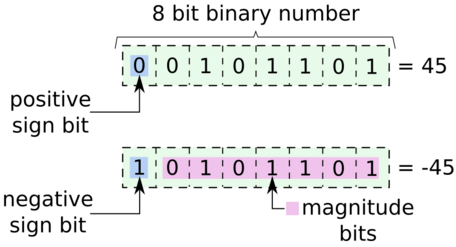



---



>E no Python, quantos bits ele usa?

Por "sorte", o Python usa _long int_ e estende a precisão no caso de inteiros se necessário, então é difícil termos problemas com inteiros em Python...Ufa!



---




### Números "reais" no computador

Agora começa o problema: como o computador representa números reais no computador?

Ele usa o que é conhecido como *ponto flutuante*, que nada mais é que uma padronização da nossa notação científica:




Mas **cuidado**, pois o computador não trabalha com base 10, e sim base 2 (binária), com ponto flutuante. Para facilitar o entendimento de alguns processos, muitos textos adotam a base 10, mas sempre temos que ter em mente que no fundo será usado a base 2.

Em 32 bits, no padrão IEEE-754 temos:


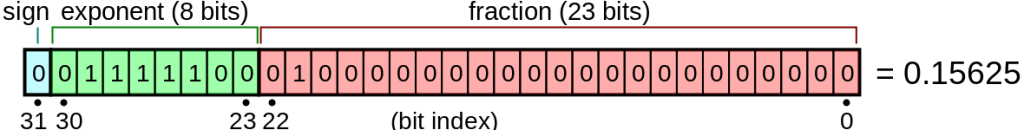

Isto é:


*   1 bit para o sinal (+/-)
*   8 bits para o expoente. Como precisamos de um sinal para o expoente, por convenção o expoente é subtraído por 127, que é 01111111 em binário (em precisão simples, float).
*   23 bits para a fração (mantissa)



*Desafio:* a parte da "fração", que gostaríamos que representasse casas "decimais", precisa ser montada com base binária! Ou seja, muitos números não serão passíveis de serem representados, ou são representados com algum erro.

Vejam alguns exemplos :





---


**Número "1"** em ponto flutuante é dado, em 32 bits, por:

$\color{blue}{0}\color{green}{01111111}\color{red}{00000000000000000000000}$

onde as cores indicam o $\color{blue}{sinal}$, o $\color{green}{expoente}$,  e a $\color{red}{mantissa}$, respectivamente.

Traduzindo (em binário ainda...):

$ (−1)^\color{blue}{0}×​2^{(\color{green}{01111111} − 01111111)​}\times ​1.\color{red}{00000000000000000000000} $

Traduzindo para decimal:
$(−1)^\color{blue}{0}×​2^{\color{green}{0}}×\color{red}{​1.0} = 1.0 $ (exato!).



---



**Número "0.5"** é só um pouco diferente do 1 em ponto flutuante é dado, em 32 bits:

No computador:
$\color{blue}{0}\color{green}{01111110}\color{red}{00000000000000000000000}$

Binário:
$ (−1)^\color{blue}{0}×​2^{(\color{green}{01111110} − 01111111)​}\times ​1.\color{red}{00000000000000000000000} $

Decimal:
$(−1)^\color{blue}{0}×​2^{\color{green}{-1}}×\color{red}{​1.0} = 0.5$ (exato!).



---


**Número "0.05"** complica, e muito, vejamos:

No computador: $\color{blue}{0}\color{green}{01111010}\color{red}{10011001100110011001101}$

Binário: $ (−1)^\color{blue}{0}×​2^{(\color{green}{01111010} − 01111111)​}\times ​1.\color{red}{10011001100110011001101} $

Decimal:
$(−1)^\color{blue}{0}×​2^{\color{green}{-5}}×1.\color{red}{60000002384185791015625} \approx 0.0500000007450580596923828125​$ - Não conseguimos representar exatamente :-( .


---



Referência: https://float.exposed/0xb3bc8b0f



---


#### ❗**Exercício**❗


1.   Qual o maior número representável em Python por aritmética de ponto flutuante no sistema que você está usando? (DICA: use a biblioteca sys.float_info (https://docs.python.org/3/library/sys.html) para saber mais sobre como o seu sistema trabalha com o tipo "float")

2.   O que acontece se chamar em Python um número maior que esse? Ou se fizer uma conta que resulte em um número maior que esse? (Dê um exemplo)

3. Quantos dígitos são bem representados nesse sistema de aritmética de ponto flutuante? (DICA: use o sys.float_info)

4. Qual o resultado da conta 1.0e-23 + 1.0e-23? Justifique.

5. Qual o resultado da conta 1.0 + 1.0e-23? Justifique.

6. Qual o resultado da conta 1.0e+14 + 1.0e-14? Justifique.

7. 🧩 (opcional) Leia o tutorial https://docs.python.org/pt-br/3/tutorial/floatingpoint.html e comente por que o computador não consegue representar o número 0.1 exatamente. Qual número aproximado é alocado na memória e usado nas contas?






In [ ]:
# 1.
print(f"1. Maior float: {sys.float_info.max}")

In [ ]:
# 2.
maior_float = sys.float_info.max
numero_maior = maior_float * 2

print(f"2. Resultado: {numero_maior}")

In [ ]:
# 3.
print(f"3. Digitos representados: {sys.float_info.dig}")

In [ ]:
# 4.
equacao_4 = 1.0e-23 + 1.0e-23
print(f"4. Resultado: {equacao_4}")

In [ ]:
# 5.
equacao_5 = 1.0 + 1.0e-23
print(f"5. Resultado: {equacao_5}")

In [ ]:
# 6.
equacao_6 = 1.0e14 + 1.0e-14
print(f"6. Resultado: {equacao_6}")

In [ ]:
# 7.
print(f"7. Representação real de 0.1 na memória: {0.1:.55f}")

**Responder aqui com texto as justificativas e observações:**

1. O maior float representável sem perder precisão é 1.7976931348623157e+308   

2. Se exceder o limite máximo de um float, ocorre overflow e o Python retorna inf (infinito) - possivelmente para evitar erros acidentais causados por overflow ocultos.

3. O número máximo de dígitos decimais que podem ser convertidos sem perder precisão para float e convertidos de volta para decimal em sistemas de 64 bits (double precision) é 15 dígitos.

4. A soma ocorre normalmente dentro da precisão disponível no sistema, com resultado 2e-23.

5.  O resultado é 1.0. Isso ocorre devido à limitação de precisão (mantissa) dos pontos flutuantes. O número 1.0e-23 é tão pequeno comparado a 1.0 que ele é arredondado para zero ao tentar alinhar os expoentes para a soma, pois a diferença é muito menor que a capacidade de representação .

6.  O resultado será 100000000000000.0. Similar ao caso anterior, a distância entre as magnitudes é de 28 ordens (10^14 vs 10^-14). Como o tipo float padrão possui apenas 15 significativos, ele não consegue armazenar o número 1 na décima quarta casa decimal e o 1 na menos décima quarta casa decimal simultaneamente, perdendo a parte menor.

7.   Computadores utilizam base 2 para representar números. Frações como 0.1 (1/10) em base decimal resultam em dízimas periódicas infinitas quando convertidas para binário, mas como a memória é finita, a representação binária é truncada, resultando em uma aproximação um pouco maior que 0.1.









---


### Simulando aritmética de ponto flutuante

Uma forma de simular a aritmética de ponto flutuante em diferentes tipos de computadores, com mais ou menos "bits" para representação numérica, é considerando o número de **algarismos significativos**.

Dada uma "máquina" com uma certa precisão, definimos o número de **algarismos significativos** como sendo o número de casas decimais, ou dígitos, que o computador consegue representar depois de transformado em notação científica.

Ex: Escreva os números na notação científica com 0,AAAAA x 10^B e verifique que

1000000 : possui 1 alg. sig.

0.00001 : possui 1 alg. sig.

1.00001 : possui 6 alg. sig.

0.12345 : possui 5 alg. sig.

Qualquer conta realizada deve ser ajustada (arredondada) no final para ficar nessa representação!



**Cuidado!**

Essa representação com algarismos significativos na base 10 é uma simplificação para fins didáticos, pois lembre-se que o computador trabalha com base 2.







---



---




Para saber esse número de algarismos (dígitos) significativos na sua máquina, use:

In [ ]:
print(sys.float_info.dig)

Em Python, podemos simular esses arredondamentos a cada operação usando a seguinte função:

In [ ]:
from math import floor, log10


# Uma opção para simular algarismos significativos
def round_alg_sig(x, sig_figs):
    # Recebe
    #    - x: numero do tipo float
    #    - sig_figs: número de algarismos significativos a ser usado
    # Devolve
    #    - Número arredondado para a aprecisão desejada

    if abs(x) > 0.0 and np.isfinite(x):
        x = float(x)
        precision = int(sig_figs)
        # Uso o round de casas decimais, deslocando as casas decimais para a posição correta
        return round(x, -int(floor(log10(abs(x)))) + (precision - 1))
    else:
        return x


#!pip install sigfig
# from sigfig import round

Um computador com 16bit tem 3 algarismos significativos (10 bits de mantissa)

(precisão conhecida como "half precision float")


Um exemplo tentando calcular $\tan(\pi/2-0.001)$ numericamente:

In [ ]:
# Computador de 16 bits (3 alg. sig.)
dig = 3

# Números em precisão dupla (64 bits)
# Python usa IEEE-754 double precision float
pi_double = np.pi
tan_double = np.tan(pi_double / 2.0 - 0.001)  # deveria ser bem grande!
print("Precisão dupla: ", pi_double, tan_double)

# Números em precisão "meia" (16 bits) simulada
# Todas as operações devem ser arredondadas!
pi_half = round_alg_sig(pi_double, dig)
tan_half = round_alg_sig(
    np.tan(round_alg_sig(round_alg_sig(pi_half / 2.0, dig) - 0.001, dig)), dig
)  # deveria ser bem grande!

print("Precisão meia :", pi_half, tan_half)



---



## Resolvendo Sistemas Lineares - Eliminação Gaussiana

Para os problemas a seguir, você deve usar uma matriz especial, construída conforme o código abaixo. Há 3 parâmetros importantes na geração da matriz:

* **n** : o tamanho da matriz
* **magic_ilong** : o seu número mágico, que fará sua matriz ser única
* **cond_pow** : Um número inteiro que quando maior, torna o sistema mais difícil de ser resolvido, por estar mais propenso a erros de arredondamento. Este número será usado na contrução do *número de condição* da matriz gerada (https://pt.wikipedia.org/wiki/N%C3%BAmero_de_condicionamento).

In [ ]:
# Sistema linear para testes - específica para cada aluno
# ------------------------------------------------------------
# Entrada:
#  n: tamanho da matriz
#  magic_ilong: seed de geração de números aleatórios
#  cond_pow : potência usada na definição do número de condição (inteiro positivo)
#
# Saída:
#   A: Matrix do sistema linear Ax=b
#   b: lado diretiro do sistema Ax=b
#   a: matriz aumentada [A|b]
def meu_sistema_linear(n=100, magic_ilong=magic_ilong, cond_pow=8):

    # Tamanho do sistema
    # n = 20

    np.random.seed(magic_ilong)

    # Gera matriz aleatória com número de condição alto usando decomposição QR
    cond = np.log(10**cond_pow)  # Numero de condição
    exp_vec = np.arange(
        -cond / 4.0, cond * (n + 1) / (4 * (n - 1)), cond / (2.0 * (n - 1))
    )[:n]
    s = np.exp(exp_vec)
    S = np.diag(s)
    U, _ = la.qr((np.random.rand(n, n) - 5.0) * 200)
    V, _ = la.qr((np.random.rand(n, n) - 5.0) * 200)
    A = U.dot(S).dot(V.T)
    A = A.dot(A.T)  # Simétrica

    # Vamos bagunçar um pouco a ordem da matriz
    trocas = np.random.randint(0, n, size=(int(n / 2), 2))
    for i, j in trocas:
        A[[i, j], :] = A[[j, i], :]

    # Vetor b - vamos gerar b tal que a solução seja sempre um vetor com 1
    x = np.ones((n))
    b = A @ x

    # Matrix aumentada a=[A|b]
    a = np.c_[A, b]

    np.set_printoptions(precision=3, suppress=True)
    # print("A:" , A[:10, :10]) #imprimir só o começo da matriz
    # print()
    # print("b:", b[:10]) #imprimir só o começo do vetor b
    # print()
    # print("a:", a) #imprimir a matriz aumentada

    return A, b, a

#### 🧩 *Reflexão*

Você consegue explicar como essa matriz é gerada e discutir suas propriedades a partir desse código?

Essa matriz é gerada através de uma construção pela decomposição de valores singulares, tal que o código utiliza a decomposição QR para criar duas matrizes ortogonais, $U$ e $V$, que garantem que a estrutura geométrica da transformação não sofra distorções.  
O núcleo da matriz é a diagonal $S$, cujos valores singulares são distribuídos de forma exponencial. Isso permite controlar o número de condição da matriz através do parâmetro cond_pow, definindo a razão entre o maior e o menor valor da diagonal.

Como o código executa $A = A\cdot A^T$, a matriz resultante é simétrica e definida positiva. Essa operação eleva o número de condição ao quadrado, tornando o sistema sensível a erros de arredondamento. Em seguida, o código realiza trocas aleatórias de linhas para quebrar a simetria visual e deslocar os elementos da diagonal principal.  
Por fim, o vetor $b$ é calculado para garantir que a solução exata seja sempre o vetor unitário ($x=[1,1,...]^T$), servindo como gabarito para medir a precisão do método numérico utilizado.




---



---



O algoritmo clássico, conforme visto em aula:

In [ ]:
# Método Clássico de Eliminação Gaussiana
#
# O método recebe como entrada uma matrix aumentada a=[A|b],
# com dimensões n linhas por n+1 colunas, tendo b na última
#
# O método retorna a solução do sistema linear Ax=b,
#            ou um erro quando isso não for possível
def elim_gauss(a_orig):
    # Faço uma cópia, para não estragar a matriz original
    a = np.copy(a_orig)

    # Número de linhas e colunas
    n, m = a.shape

    # Vetor da solução
    x = np.empty((n))

    # Verifica se usuário forneceu uma matriz no formato certo
    if m != n + 1:
        print("Essa matriz não tem dimensões adequadas:", n, m)
        return x

    # Escalonamento
    zero_eps = 10e-16
    for j in range(n):  # Colunas
        # print(j, a)
        # Caso o pivot seja zero (ou próximo de zero)
        if np.abs(a[j, j]) < zero_eps:
            # Pivotar linha i com linha linha com pivot não nulo!
            ktroca = j
            for k in range(j + 1, n):
                if np.abs(a[k, j]) > zero_eps:
                    ktroca = k
                    break
            # Troca as linhas
            if ktroca != j:
                print("Troquei linha ", j, " pela linha ", ktroca)
                a[[j, ktroca], :] = a[[ktroca, j], :]
            else:
                print("Esse sistema tem determinante nulo, ou muito perto de zero.")
                return x

        # Escalonamento
        for i in range(j + 1, n):  # linhas
            ratio = a[i, j] / a[j, j]
            for k in range(n + 1):
                a[i, k] = a[i, k] - ratio * a[j, k]

    # Substituição
    x[n - 1] = a[n - 1, n] / a[n - 1, n - 1]

    for i in range(n - 2, -1, -1):
        x[i] = a[i, n]

        for j in range(i + 1, n):
            x[i] = x[i] - a[i, j] * x[j]

        x[i] = x[i] / a[i, i]

    return x

Vamos fazer um teste com uma matriz aleatória especial

Vamos testar o nosso esquema usando uma matriz gerada com parâmetros:

* n = 300

In [ ]:
A, b, a = meu_sistema_linear(300, magic_ilong)

start_time = time.time()
x = elim_gauss(a)
tempo_orig = time.time() - start_time

print("Solução", x[:10])  # imprime só alguns elementos da solução
print(
    "\n\nResíduo max|b-Ax|: ",
    np.max(np.abs(b - A @ x)),
    " Tempo que levou: ",
    tempo_orig,
    " segundos",
)

#### ❗**Exercício**❗ O Desafio da Precisão

**Parte 1 - O Cálculo Exato:**
Resolva manualmente (no papel) o seguinte sistema linear $Ax = b$:
$$
\begin{cases}
1000x + 999y = 1999 \\
999x + 998y = 1997
\end{cases}
$$
*Dica: Use substituição ou o método de eliminação simples.*

**Parte 2 - O Erro de Medição:**
Agora, imagine que esses dados vieram de um sensor de alta precisão, mas houve um ruído térmico minúsculo. Ao passar para o computador, o vetor $b$ foi registrado como:
$$b_{novo} = \begin{bmatrix} 1998.99 \\ 1997.01 \end{bmatrix}$$
Ou seja, uma variação de apenas **0.01** em cada valor. Resolva este novo sistema manualmente.

Compare os dois resultados. A variação na resposta ($x, y$) foi proporcional à variação nos dados de entrada ($0.01$)? O que isso diz sobre a confiabilidade de um sistema de controle baseado nesses cálculos? Justifique geométricamente o motivo da solução real ser deslocada para a obtida na parte 2 (Dica: veja que ambos os sistemas são representados por retas).

1. O resultado original era (1,1). O novo resultado é (20.97,−18.99). A variação na resposta foi gigante, completamente desproporcional à variação de apenas 0.01 nos dados de entrada.

2. Isso demonstra que um sistema de controle baseado nesses cálculos seria extremamente inconfiável. Se um sensor tiver um erro mínimo, o atuador do sistema poderia receber um comando 20 vezes maior que o esperado ou em sentido contrário (como no eixo Y que foi de 1 para -18.99), sendo portanto um sistema mal condicionado.

3. Geometricamente, as duas equações representam retas no plano cartesiano e, como os coeficientes 1000/999 e 999/998 são extremamente próximos, as duas retas são quase paralelas.  
Quando duas retas são quase paralelas, Um deslocamento minúsculo em uma das retas faz com que o ponto de cruzamento deslize muito para longe da posição original.

Adicione aqui as soluções obtidas. Você é capaz de apontar dois motivos que justifiquem o resultado obtido?

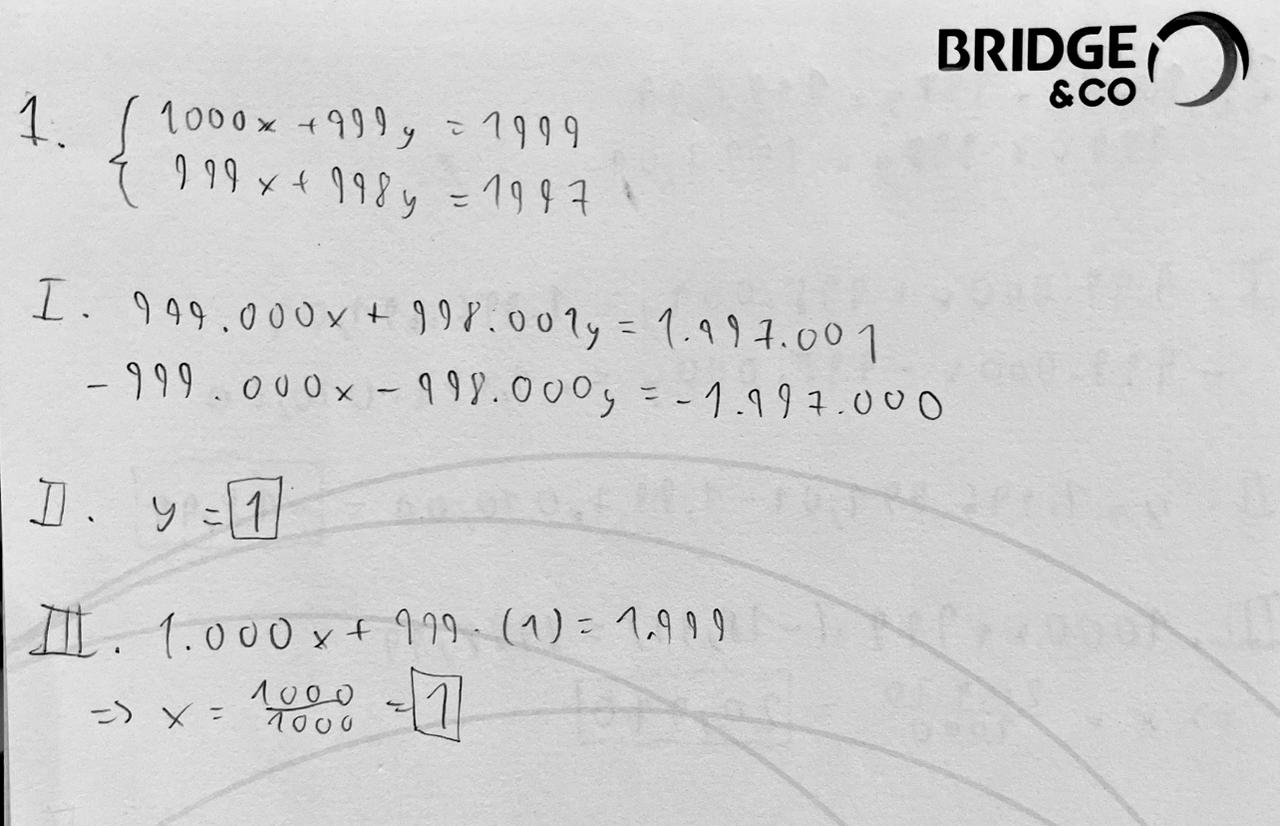

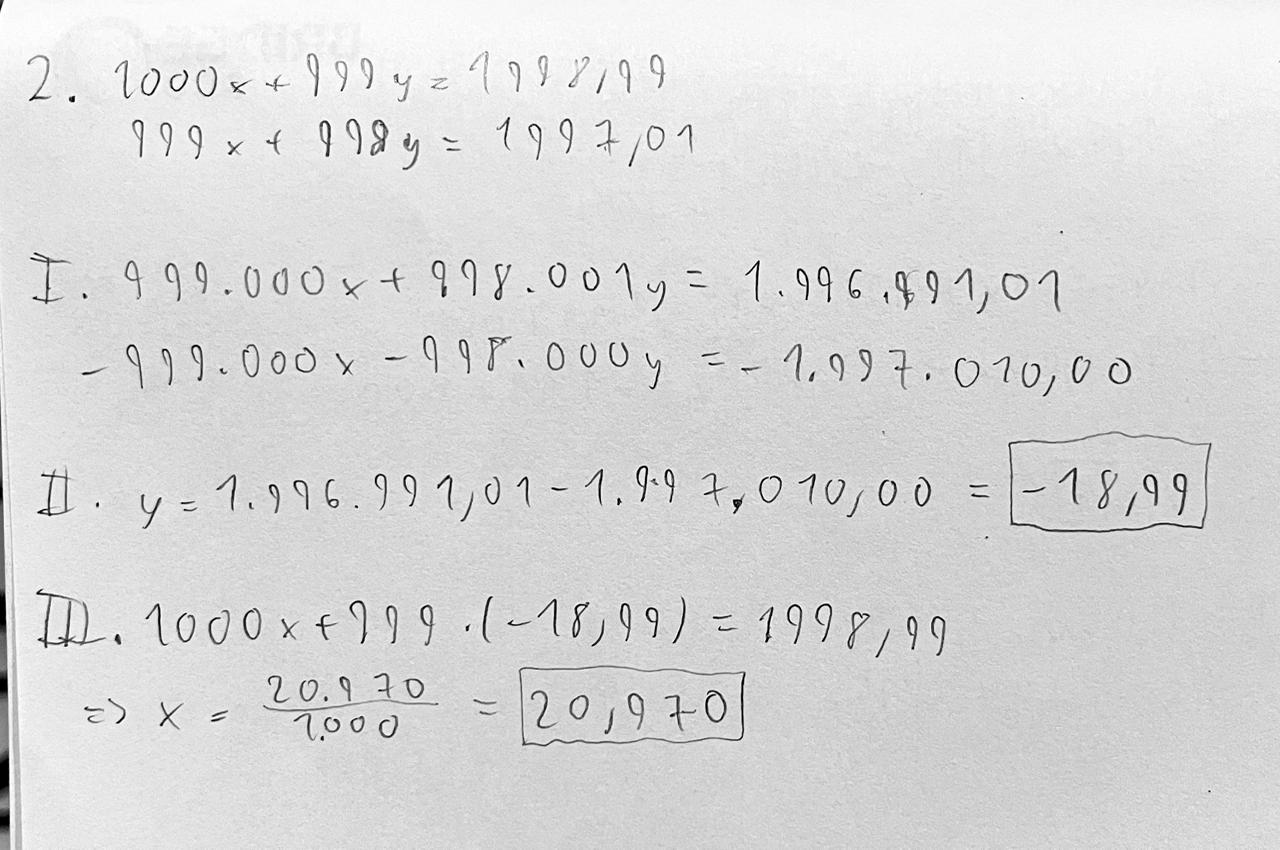

1. As duas equações representam retas no plano cartesiano. Como os coeficientes são extremamente próximos, as inclinações das retas são praticamente idênticas. Quando duas retas são quase paralelas, o ponto de intersecção é instável: um deslocamento minúsculo em uma das retas faz o ponto de cruzamento deslizar drasticamente para longe da posição original. Se as retas fossem perfeitamente perpendiculares, o ponto de interseção então seria completamente estável.

2. O sistema é mal condicionado. As linhas da matriz de coeficientes são quase linearmente dependentes (a primeira equação é quase igual à segunda). Em termos numéricos, sistemas com alto número de condição agem como amplificadores de erro: uma pequena perturbação na entrada é multiplicada por um fator grande, gerando uma grande perturbação na saída.

## Precisão reduzida

Gostaríamos de simular o caso de termos uma máquina com precisão (número de algarismos significativos) baixa.

A seguir temos uma implementação análoga à apresentada no primeiro código de eliminação de Gauss (a função elim_gauss()), mas que agora arredonda cada operação feita para um certo número de algarismos significations. Aqui usamos a função round(número, sigfigs) após cada conta que realizar no algoritmo. TODAS as contas de +-*/ devem ser sempre arredondadas!


In [ ]:
# Essa função já foi declarada anteriormente!

# from math import floor, log10
# Uma opção para simular algarismos significativos
# def round_alg_sig(x, sig_figs):
#    # Recebe
#    #    - x: numero do tipo float
#    #    - sig_figs: número de algarismos significativos a ser usado
#    # Devolve
#    #    - Número arredondado para a aprecisão desejada#
#
#    if abs(x) > 0.0 and np.isfinite(x):
#      x = float(x)
#      precision = int(sig_figs)
#      # Uso o round de casas decimais, deslocando as casas decimais para a posição correta
#      return round(x, -int(floor(log10(abs(x)))) + (precision - 1))
#    else:
#      return x

# Outra opção - automatizada
#!pip install sigfig
# from sigfig import round
# round(3.14159, sigfigs=2)

In [ ]:
# Método Clássico de Eliminação Gaussiana com aritmética de ponto flutuante restrita
#
# O método recebe como entrada uma matrix aumentada a=[A,b] referente ao
#    sistema linear Ax=b, com A (n x n) e o vetor b (n x 1),
# O método recebe também o número de algarismos significativos a serem usados nas contas
#
# O método retorna a solução do sistema linear Ax=b,
#            ou um erro quando isso não for possível
def elim_gauss_precisao_reduzida(a_orig, sigfig=17):

    # Faço uma cópia, para não estragar a matriz original
    a = np.copy(a_orig)

    # Número de linhas e colunas
    n, m = a.shape

    # Vetor da solução
    x = np.empty((n))

    # Verifica se usuário forneceu uma matriz no formato certo
    if m != n + 1:
        print("Essa matriz não tem dimensões adequadas:", n, m)
        return x

    zero_eps = 10e-16
    # Escalonamento
    for j in range(n):  # colunas

        # Caso o pivot seja zero (ou próximo de zero)
        if np.abs(a[j, j]) < zero_eps:
            # Pivotar linha i com linha linha com pivot não nulo!
            ktroca = j
            for k in range(j + 1, n):
                if np.abs(a[k, j]) > zero_eps:
                    ktroca = k
                    break
            # Troca as linhas
            if ktroca != j:
                print("Troquei linha ", j, " pela linha ", ktroca)
                a[[j, ktroca], :] = a[[ktroca, j], :]
            else:
                print("Esse sistema tem determinante nulo, ou muito perto de zero.")
                return x

        for i in range(j + 1, n):  # linhas
            ratio = round_alg_sig(a[i, j] / a[j, j], sigfig)
            for k in range(n + 1):
                a[i, k] = round_alg_sig(
                    a[i, k] - round_alg_sig(ratio * a[j, k], sigfig), sigfig
                )

    # Substituição
    x[n - 1] = round_alg_sig(a[n - 1, n] / a[n - 1, n - 1], sigfig)
    for i in range(n - 2, -1, -1):
        x[i] = a[i, n]
        for j in range(i + 1, n):
            x[i] = round_alg_sig(x[i] - round_alg_sig(a[i, j] * x[j], sigfig), sigfig)
        x[i] = round_alg_sig(x[i] / a[i, i], sigfig)

    return x

###❗Exercício ❗

Teste a resolução do seu sistema linear personalizado com dimensão 30 variando o número de algarísmos significativos e reporte os seguintes casos:

1. Erro com 7 algarismos significativos
2. Erro com 8 algarismos significativos
3. Erro com 9 algarismos significativos

Quantos algarismos significativos precisamos para ficarmos com um erro menor que 10e-4?

In [ ]:
n = 30

A_mat, b_vec, a_aug = meu_sistema_linear(n=n, magic_ilong=magic_ilong, cond_pow=8)
x = np.ones(n)

In [ ]:
for algarismos in [7, 8, 9]:
    x_calc = elim_gauss_precisao_reduzida(a_aug, sigfig=algarismos)
    erro = np.linalg.norm(x_calc - x, np.inf)
    print(f"Algarismos Significativos: {algarismos} | Erro Absoluto Máximo: {erro:.5e}")

In [ ]:
erro_esperado = 10e-4
for sig in range(7, 100):
    x_calc = elim_gauss_precisao_reduzida(a_aug, sigfig=sig)
    erro = np.linalg.norm(x_calc - x, np.inf)
    if erro < erro_esperado:
        print(f"{sig} algarismos significativos.")
        print(f"Erro obtido: {erro:.5e}")
        break

Resposta:

Os erros respectivos foram 1.01772e+01, 2.15200e-01 e 1.08127e-01.

Precisamos de 11 algarismos significativos de precisão para conseguir o erro menor que 10e-4



---



## Pivotamento Parcial
Reduzindo erros de artitmética de ponto flutuante permutando linhas.

A *condensação pivotal parcial* consiste em escolher como pivô, a cada passo do escalonamento, o elemento na coluna-pivô (da diagonal principal para baixo) com maior valor absoluto, de modo que todos os multiplicadores tenham módulo menor ou igual a 1.

O algoritmo consiste na seguinte estratégia:
1. Na eliminação de Gauss o pivô é termo da diagonal que será usado como divisor para chegarmos no multiplicador. Queremos que o pivô usado para construção do multiplicador seja o maior possível, para que o multiplicador seja menor que 1.
2. A cada nova coluna que vou escalonar (digamos que seja a coluna j, com o pivô sendo $a_{jj}$), verifico o valor em módulo dos elementos abaixo do pivô (elementos $a_{kj}$, $k\geq j$). Escolho a linha ($k$) que tem o elemento com maior valor em módulo, e troco com a linha principal ($j$), isto é, troco a linha j com a k.  
3. Prossigo com a estratégia usual de escalonamento com a matriz com as linhas trocadas. Note que solução do sistema não é alterada pela troca de linhas. Além disso, note ainda que não "estragamos" o escalonamento anterior, pois sempre trocamos com linhas abaixo do pivô.

Para mais detalhes, veja a video-aula https://drive.google.com/file/d/1h2UJUaQvEYR7mO00fiJoihJmeTwv42BU/view?usp=sharing.



---





Verifique que com sigfig=17 e sem pivotamento o resultado obtido com esse método é identico ao da nossa implementação ingênua.



#### ❗**Exercício**❗


1. Implemente uma modificação do algoritmo de eliminação de Gauss com precisão reduzida agora considerando um **pivotamento parcial**, trocando as linhas nas etapas do escalonamento de forma a sempre obter um multiplicador em módulo menor que 1.

2. Verifique que com sigfig=17 e sem pivotamento o resultado obtido com esse método é identico ao da nossa implementação ingênua.

3. Resolva o seu problema personalizado com n=30 com 8, 9, 10 algarismos significativos. Compare os erros e resíduos obtidos com e sem pivotamento.

In [ ]:
def elim_gauss_pivotamento_precisao(a_orig, sigfig=17):
    a = np.copy(a_orig)
    n = a.shape[0]
    x = np.empty((n))

    # Escalonamento
    for j in range(n):

        # Pivotamento parcial
        pivot_idx = np.argmax(np.abs(a[j:n, j])) + j

        # Troca as linhas
        if pivot_idx != j:
            a[[j, pivot_idx], :] = a[[pivot_idx, j], :]

        # Verifica o pivô
        if np.abs(a[j, j]) < 1e-15:
            pass

        # Eliminação Gaussiana
        for i in range(j + 1, n):
            ratio = round_alg_sig(a[i, j] / a[j, j], sigfig)
            for k in range(j, n + 1):  # Calcula apenas de j em diante
                a[i, k] = round_alg_sig(
                    a[i, k] - round_alg_sig(ratio * a[j, k], sigfig), sigfig
                )

        x[n - 1] = round_alg_sig(a[n - 1, n] / a[n - 1, n - 1], sigfig)
        for i in range(n - 2, -1, -1):
            soma = 0
            for j in range(i + 1, n):
                soma = round_alg_sig(
                    soma + round_alg_sig(a[i, j] * x[j], sigfig), sigfig
                )

            x[i] = round_alg_sig((a[i, n] - soma) / a[i, i], sigfig)

    return x

In [ ]:
x_reduzido = elim_gauss_precisao_reduzida(a_aug, sigfig=17)
x_preciso = elim_gauss_pivotamento_precisao(a_aug, sigfig=17)

diff = np.linalg.norm(x_reduzido - x_preciso, np.inf)

print(f"Diferença entre métodos: {diff:.2e}")

In [ ]:
for sig in [8, 9, 10]:
    x_s = elim_gauss_precisao_reduzida(a_aug, sigfig=sig)
    err_s = np.linalg.norm(x_s - x_preciso, np.inf)

    x_c = elim_gauss_pivotamento_precisao(a_aug, sigfig=sig)
    err_c = np.linalg.norm(x_c - x_preciso, np.inf)

    diferenca = err_s / err_c

    print(f"Sigfigs: {sig}")
    print(f"  Erro sem pivotamento: {err_s:.5e}")
    print(f"  Erro com pivotamento: {err_c:.5e}")
    print(f"  Diferença: {diferenca:.1f}x menor\n")



---



Coloque aqui observações sobre o experimento realizado:

* A precisão da solução melhorou com o pivotamento? Quanto?
* Isso depende da precisão das contas?
* 🧩 Será que para qualquer matriz o erro vai sempre melhorar?
* 🧩 Consegue ilustrar algum teste que o pivotamento não ajuda?


1. Sim, drasticamente. Para matrizes mal condicionadas ou grandes, o método sem pivotamento tende a acumular erros quando encontra pivôs pequenos, já que dividir por um número pequeno ($<1$) multiplica o erro das operações subsequentes. O pivotamento garante que dividimos pelo maior número possível, mantendo os multiplicadores da eliminação $\le 1$.
    
2. Sim. Quanto menor o número de algarismos significativos, mais crítico se torna o pivotamento. Com precisão infinita, ambos dariam o mesmo resultado.

3. Não necessariamente. Se a matriz já for diagonalmente dominante (os maiores elementos já estão na diagonal principal), o pivotamento parcial pode não realizar trocas, resultando no mesmo cálculo e exato mesmo erro. Além disso, para matrizes muito mal condicionadas, mesmo o pivotamento pode não ser suficiente para evitar erros grandes.

4. O pivotamento parcial falha ou ajuda pouco se a matriz tiver desequilíbrio de escala entre linhas (uma linha multiplicada por $10^{-10}$ e outra por $10^{10}$). Nesses casos, apenas trocar linhas pode não bastar; seria necessário um pivotamento total (troca de linhas e colunas) ou reescalonamento da matriz antes de começar.